In [5]:
# imports
import HTSeq

from price2.reference_annotation import ReferenceAnnotation
from price2.orf_activity_estimator import ORFActivityEstimator

from matplotlib import pyplot as plt
import numpy as np

In [6]:
# paths
directory = '/projects/viro/maidhof/price2/orf_deconvolution_development/data_advanced/runs'
gtf_path = f'{directory}/orf_deconvolution.gtf'
fasta_path = f'{directory}/generated_data/orf_deconvolution.fasta'
bam_dir = f'{directory}/generated_data'

In [7]:
ra = ReferenceAnnotation(gtf_path)
genome = dict((s.name, s) for s in HTSeq.FastaReader(fasta_path))

oae = ORFActivityEstimator(bam_dir, ra)

In [8]:
oae.estimate_activity(genome)

In [9]:
################## plot results #####################

orf_gtf = '/projects/viro/maidhof/price2/orf_deconvolution_development/data_advanced/orf_deconvolution_ORFs.gtf'
gtf = '/projects/viro/maidhof/price2/orf_deconvolution_development/data_advanced/orf_deconvolution.gtf'
from price2.genomic_region import GenomicRegion

class PlotRGR:
    type: str
    genomic_region: GenomicRegion
    activity: float

    def __init__(self, type, activity, chrom, strand):
        self.type = type
        self.activity = activity
        self.genomic_region = GenomicRegion([], chrom, strand)

ground_truth_rgrs = {}

for orf in HTSeq.GFF_Reader(orf_gtf):
    if not orf.attr['ID'] in ground_truth_rgrs:
        ground_truth_rgrs[orf.attr['ID']] = PlotRGR(
            'ORF',
            int(orf.attr['activity']),
            orf.iv.chrom,
            orf.iv.strand,
            )

    ground_truth_rgrs[orf.attr['ID']].genomic_region.add_interval(orf.iv)

for region in HTSeq.GFF_Reader(gtf):
    if region.type != 'exon' and region.type != 'transcript':
        continue
    if region.type == 'transcript':
        if not region.attr['transcript_id'] in ground_truth_rgrs:
            ground_truth_rgrs[region.attr['transcript_id']] = PlotRGR(
                'NOISE',
                int(region.attr['activity']),
                region.iv.chrom,
                region.iv.strand,
                )
    if region.type == 'exon':
        ground_truth_rgrs[region.attr['transcript_id']].genomic_region.add_interval(region.iv)




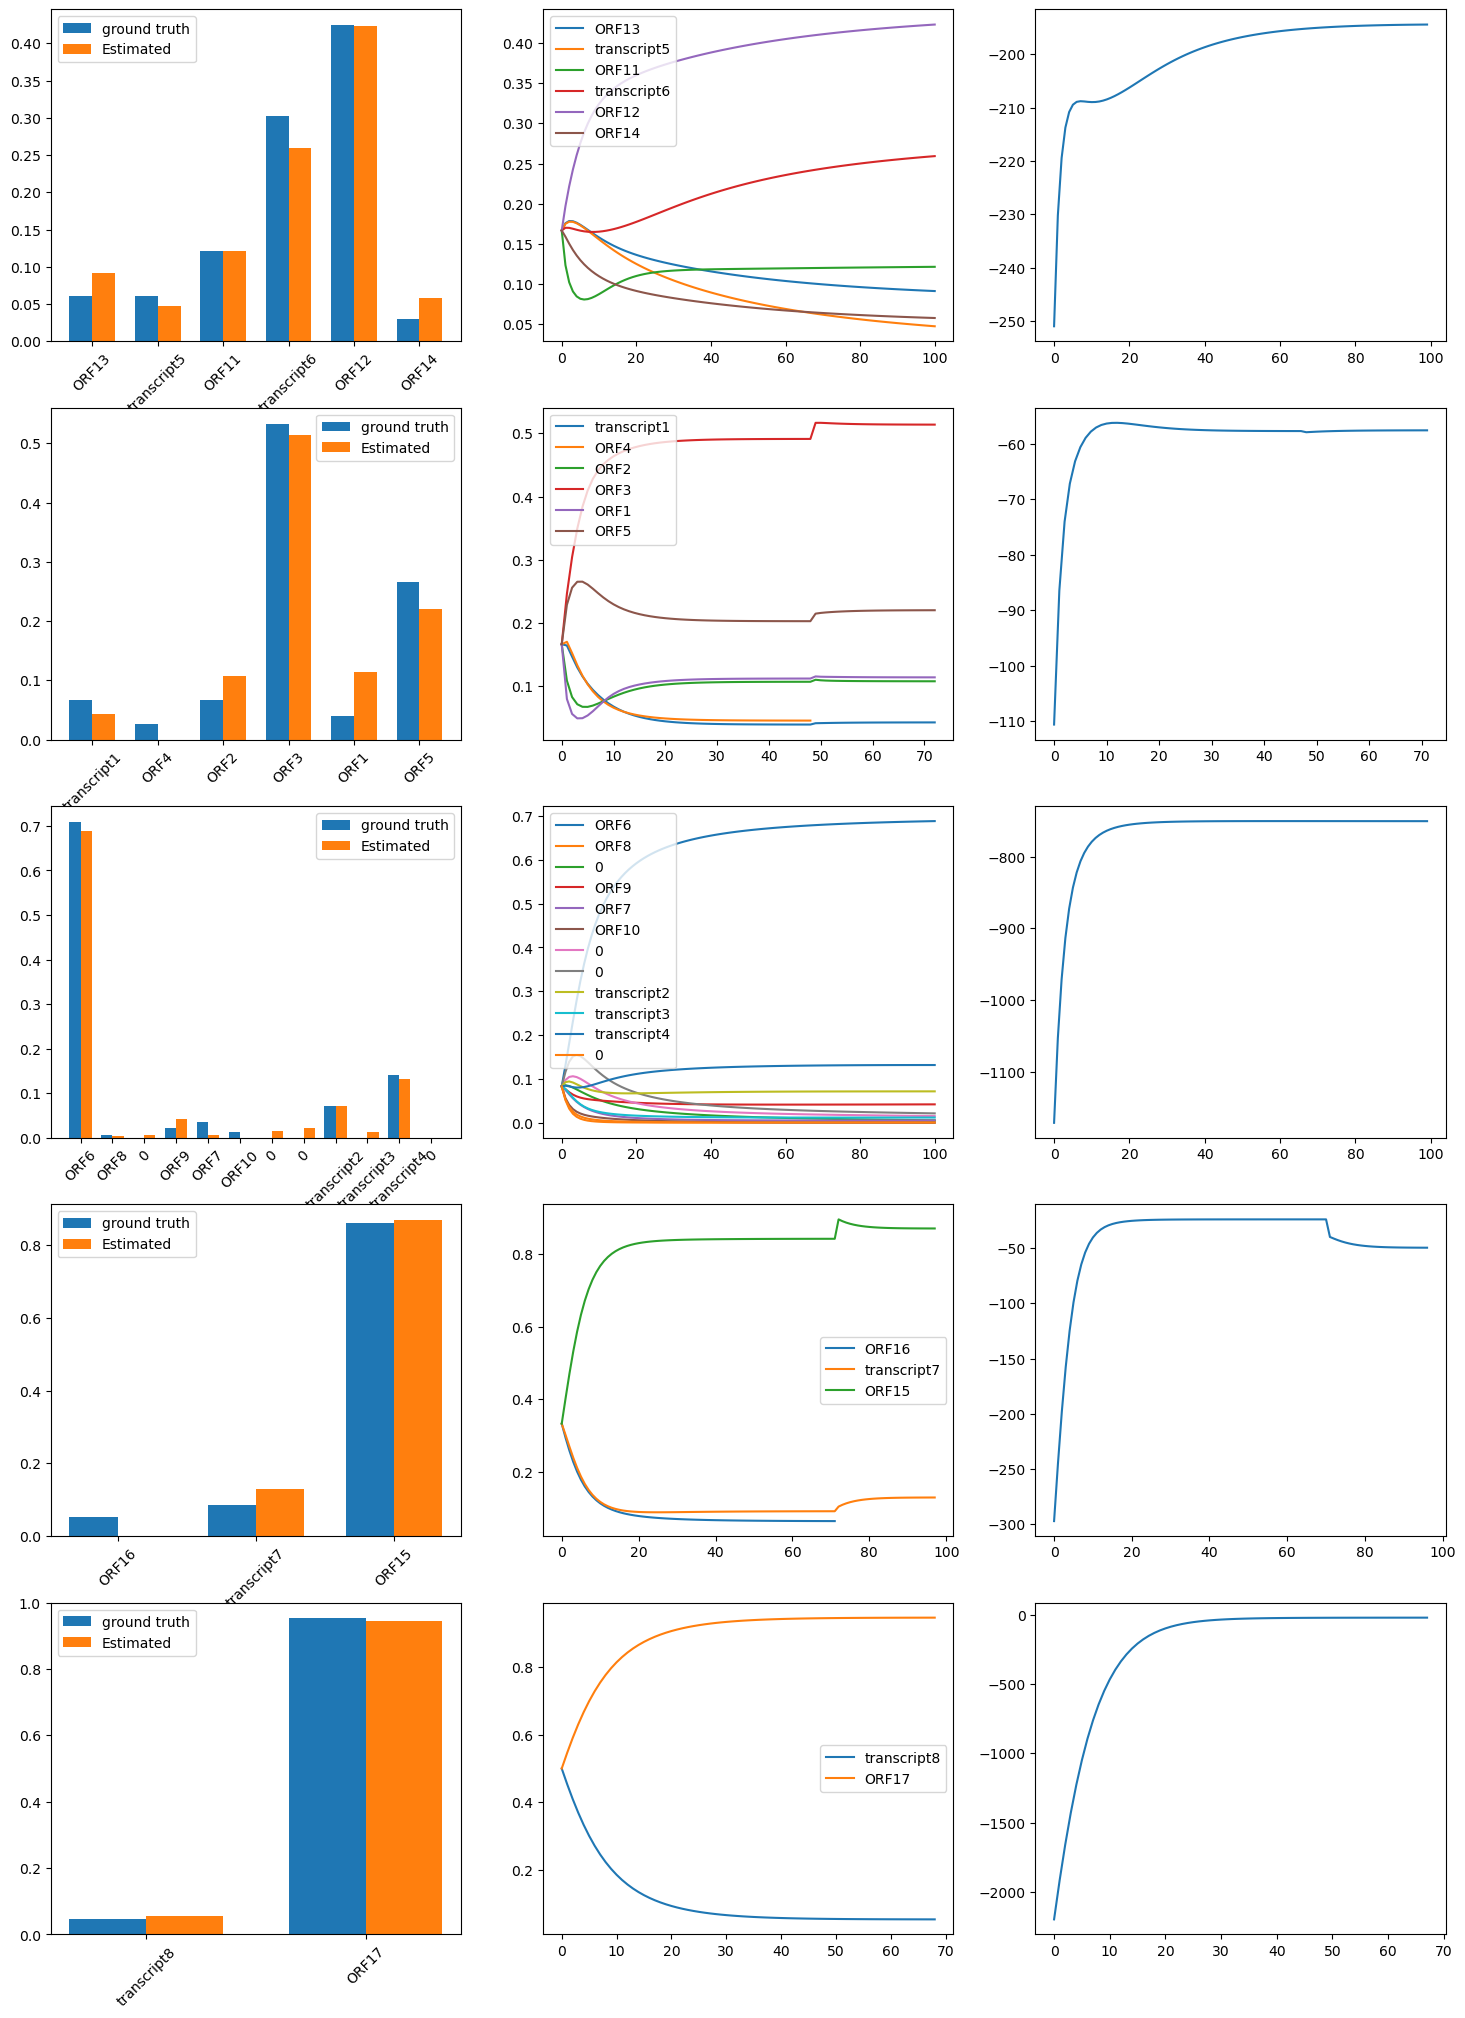

In [10]:
fig, axs = plt.subplots(len(oae.loci_set), 3, figsize=(18, 5*len(oae.loci_set)))


loci_list = list(oae.loci_set)
for i in range(len(loci_list)):
    ids = []
    true_activities = []
    estimated_activities = []
    activity_progression = []

    for region in loci_list[i].rgr_set:
        estimated_activities.append(region.average_activity)
        for id, rgr in ground_truth_rgrs.items():
            if rgr == region:
                true_activities.append(rgr.activity)
                ids.append(id)
                break
        if len(true_activities) < len(estimated_activities):
            true_activities.append(0)
            ids.append('0')

        
        axs[i,1].plot(loci_list[i].average_activities[region], label=ids[-1])
    axs[i,1].legend()
        

    estimated_activities = np.array(estimated_activities)
    estimated_activities = estimated_activities / estimated_activities.sum()
    true_activities = np.array(true_activities)
    true_activities = true_activities / true_activities.sum()

    bar_width = 0.35

    axs[i,0].bar([x-bar_width/2 for x in range(1,len(true_activities)+1)], true_activities, width=bar_width, label='ground truth')
    axs[i,0].bar([x+bar_width/2 for x in range(1,len(true_activities)+1)], estimated_activities, width=bar_width, label='Estimated')
    axs[i,0].legend()
    axs[i,0].set_xticks([x for x in range(1,len(true_activities)+1)], ids)
    for tick in axs[i,0].get_xticklabels():
        tick.set_rotation(45)

    axs[i, 2].plot(loci_list[i].lls)

